# Pillbox Analysis

In [1]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
from core.em_project import EMProject

%matplotlib widget
plt.rcParams['figure.dpi'] = 100

# Create project

In [2]:
project_name = 'Pillbox'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

Project 'Pillbox' exists. Loading automatically...
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['cell_1']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (external, output)']
Restored PortEigenmodeSolver with 2 ports, 6 total modes
FrequencyDomainSolver state loaded from C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\Pillbox\fds
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['cell_1']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (external, output)']


## Define Geometry

In [3]:
# 1. Load and prepare geometry
geo = proj.import_geometry(r"./pillbox.step", unit='m', auto_build=False)
geo.build()
geo.name_solids(port_axis='x')
geo.generate_mesh(maxh=0.05) # after naming solids, must generate mesh but avoid rebuilding
geo.print_info()


STEP Geometry Information
File: ./pillbox.step
Unit: m
Number of solids: 1
Is split: False
Number of splitting planes: 0

Bounding Box:
  Min: (-0.7000, -0.3000, -0.3000)
  Max: (0.7000, 0.3000, 0.3000)
  Size: (1.4000, 0.6000, 0.6000)

NGSolve geometry built: True
Mesh generated: True


In [4]:
geo.show('mesh')
geo.print_info()

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…


STEP Geometry Information
File: ./pillbox.step
Unit: m
Number of solids: 1
Is split: False
Number of splitting planes: 0

Bounding Box:
  Min: (-0.7000, -0.3000, -0.3000)
  Max: (0.7000, 0.3000, 0.3000)
  Size: (1.4000, 0.6000, 0.6000)

NGSolve geometry built: True
Mesh generated: True


In [5]:
fom_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 1000,
    'fmin': 1e-3,
    'fmax': 2,
    'solver_type': 'direct',
    # 'iterative_opts': {
    #     'precond': 'bddc',
    #     'maxsteps': 500,
    # },
    'rerun': True
}
fom_result = proj.fds.solve(config=fom_config)


Frequency Domain Solve Configuration
Frequency range: 0.0010 - 2.0000 GHz
Number of samples: 1000
Structure type: Single
Per-domain solve: False
Global method: coupled
Global Coupled Solve
  
Coupled solve complete: 2 external ports in 876.01s
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\Pillbox\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\Pillbox\fds


Loaded CST S-parameters from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


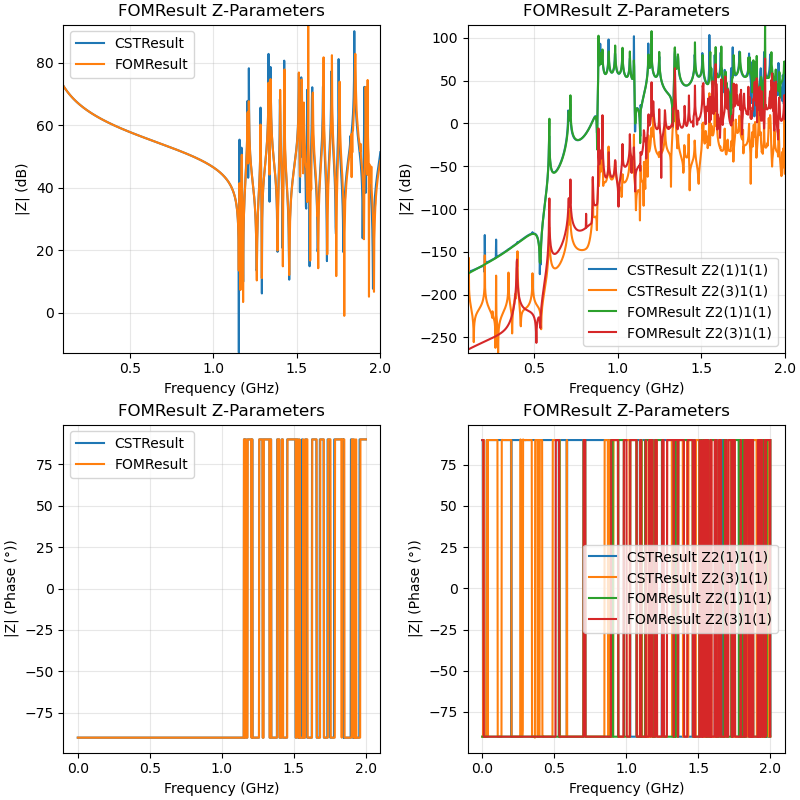

In [6]:
from analytical.cst_result import CSTResult

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')
# plot comparison
which = [['1(3)1(3)'], ['2(1)1(1)', '2(3)1(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1])
    proj.fds.fom.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.fom.plot_z(wh, plot_type='phase', ax=axs[idx+3])
    axs[idx+1].set_xlim(0.1, 2)
    ys = [y for line in axs[idx+1].get_lines() for x, y in zip(line.get_xdata(), line.get_ydata()) if 0.1 <= x <= 2]
    axs[idx+1].set_ylim(min(ys), max(ys))

In [7]:
# Reduce model order
rom = proj.fds.fom.reduce(tol=1e-15)
# concat = proj.fds.fom.rom.concatenate()
rom_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 2,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    'rerun': True
}
rom_result = rom.solve(config=rom_config) # solve reduced order model on more frequency samples



Model Order Reduction
INFO:: 
Domain: cell_1
Total: 57636 → 671 DOFs
Overall compression: 98.8%
  Solve loop: 2.024s (1000 freq points)


Loaded CST S-parameters from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


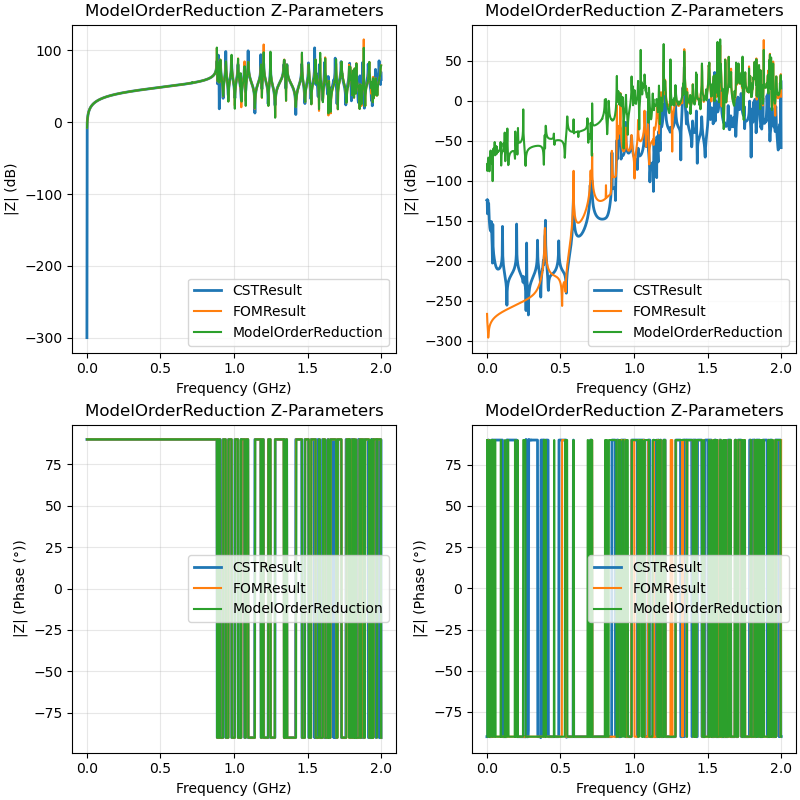

In [11]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1], lw=2)
    proj.fds.fom.plot_z(wh, ax=axs[idx+1])#, marker='o', lw=0)
    rom.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3], lw=2)
    (proj.fds.
     fom.plot_z(wh, plot_type='phase', ax=axs[idx+3]))#, marker='o', lw=0))
    rom.plot_z(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

  Note: global residuals are zero. This is expected when using a direct solver (solver_type='direct').


(<Figure size 600x600 with 2 Axes>,
 (<Axes: title={'center': 'global Iterative Solver Convergence (iter avg, residual min)'}, xlabel='Frequency (GHz)', ylabel='GMRES Iterations'>,
  <Axes: ylabel='Relative Residual'>))

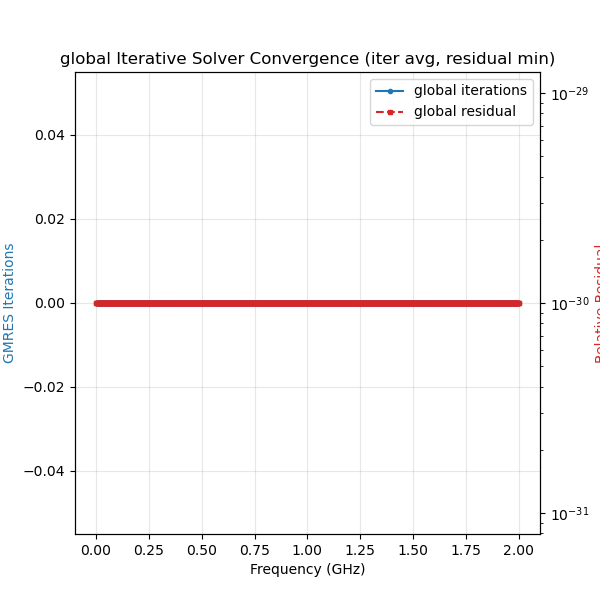

In [9]:
proj.fds.fom.plot_residual(figsize=(6, 6))

In [13]:
evals, evecs = proj.fds.fom.rom.calculate_resonant_modes()

(<Figure size 600x400 with 1 Axes>,
 <Axes: label='1', title={'center': 'ModelOrderReduction Eigenfrequencies'}, xlabel='Frequency (GHz)'>)

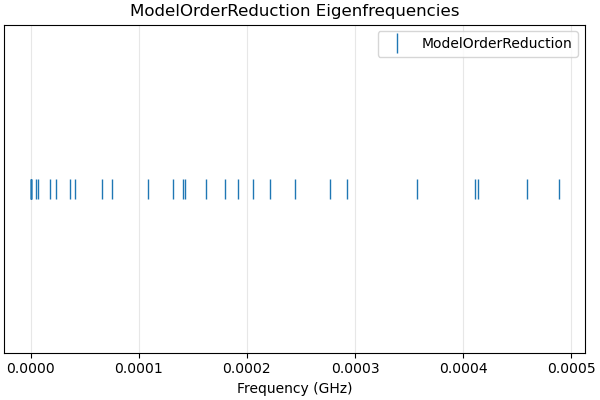

In [19]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

# plot comparison
fig, axs = plt.subplot_mosaic([[1]], figsize=(6, 4), layout='constrained')
# proj.fds.fom.plot_eigenvalues(ax=axs[1])#, marker='o', lw=0)
rom.plot_eigenvalues(ax=axs[1])
# plt.show()